# 8. Redes Generativas Antagónicas (GANs) 🎨

En este notebook aprenderás los fundamentos de las GANs, cómo entrenar un generador y un discriminador, y verás ejemplos prácticos con TensorFlow/Keras.

✨ **Highlights:**
- Implementación de una GAN con BatchNormalization y label smoothing
- Monitoreo de convergencia mediante curvas de pérdida
- Diagnóstico visual de mode collapse
- Evolución de imágenes generadas a lo largo del entrenamiento

## Objetivo
- Comprender la teoría y arquitectura de las GANs.
- Implementar y entrenar una GAN para generación de dígitos.
- Analizar el impacto de los hiperparámetros y visualizar resultados.
- Aplicar buenas prácticas para entrenamiento estable.

## Prerequisitos

> 📌 **Prerequisitos:** Haber completado los notebooks [04 (MLP)](./04_redes_neuronales_capa_densa.ipynb) y [05 (CNN)](./05_redes_convolucionales_cnn.ipynb).

- Conceptos de redes neuronales, funciones de activación y entrenamiento con Keras.

## 1. Introducción teórica

Las GANs consisten en dos redes que compiten entre sí:

- **Generador:** Crea datos falsos a partir de ruido aleatorio.
- **Discriminador:** Intenta distinguir entre datos reales y generados.

El entrenamiento es un «juego» donde ambas redes mejoran mutuamente.

**Ventajas:** Capaces de generar datos hiperrealistas (imágenes, audio).  
**Desventajas:** Difíciles de entrenar (inestabilidad, mode collapse).

## 2. Importación de librerías

In [1]:
import random
import numpy as np
import os
import logging

# === Reproducibilidad ===
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Suprimir logs de XLA/oneDNN antes de importar TF
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
logging.getLogger('tensorflow').setLevel(logging.ERROR)

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
tf.random.set_seed(SEED)

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# === Información del dispositivo ===
print(f'TensorFlow: {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs disponibles: {len(gpus)}')
if gpus:
    for gpu in gpus:
        print(f'  ✅ {gpu.name}')
else:
    print('  ⚠️  Sin GPU — el entrenamiento será más lento')
print('─' * 50)

TensorFlow: 2.21.0
GPUs disponibles: 1
  ✅ /physical_device:GPU:0
──────────────────────────────────────────────────


## 3. Carga de datos y definición de la GAN

Crearemos una GAN para generar dígitos similares a MNIST. El generador usa **BatchNormalization** para mejorar la estabilidad.

In [2]:
# Cargar MNIST
(X_train, _), (_, _) = keras.datasets.mnist.load_data()
X_train = X_train.astype('float32') / 255.0
X_train = X_train.reshape(-1, 28*28)

LATENT_DIM = 100

# Generador con BatchNormalization (buena práctica)
def build_generator(latent_dim=LATENT_DIM):
    model = keras.Sequential([
        keras.layers.Dense(128, input_dim=latent_dim),
        keras.layers.BatchNormalization(),
        keras.layers.LeakyReLU(0.2),
        keras.layers.Dense(256),
        keras.layers.BatchNormalization(),
        keras.layers.LeakyReLU(0.2),
        keras.layers.Dense(28*28, activation='sigmoid')
    ])
    return model

# Discriminador con LeakyReLU
def build_discriminator():
    model = keras.Sequential([
        keras.layers.Dense(256, input_dim=28*28),
        keras.layers.LeakyReLU(0.2),
        keras.layers.Dense(128),
        keras.layers.LeakyReLU(0.2),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    return model

generator = build_generator()
discriminator = build_discriminator()
discriminator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

discriminator.trainable = False

# Modelo GAN combinado
z = keras.Input(shape=(LATENT_DIM,))
img = generator(z)
valid = discriminator(img)
gan = keras.Model(z, valid)
gan.compile(optimizer='adam', loss='binary_crossentropy')

print('Generador:')
generator.summary()
print('\nDiscriminador:')
discriminator.summary()

Generador:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 248,976 (972.56 KB)

 Trainable params: 248,208 (969.56 KB)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 233,985 (914.00 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 233,985 (914.00 KB)

## 4. Entrenamiento de la GAN

Entrenamos alternando discriminador y generador. Usamos **label smoothing** (etiquetas reales = 0.9 en lugar de 1.0) para estabilizar.

Epoch    0/500 | D loss: 0.7362, acc: 25.0% | G loss: 0.8994 | ⏱ 7.1s


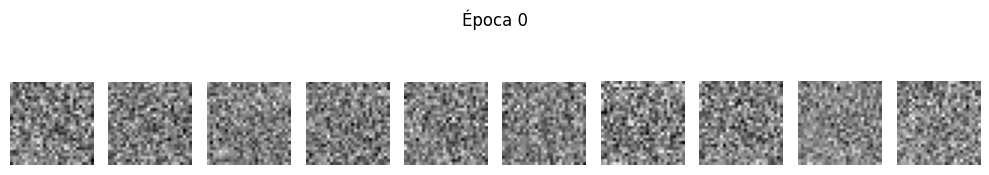

  ⚠️  Posible mode collapse detectado (similitud promedio: 0.968)
Epoch  100/500 | D loss: 2.0620, acc: 1.1% | G loss: 0.0340 | ⏱ 15.1s


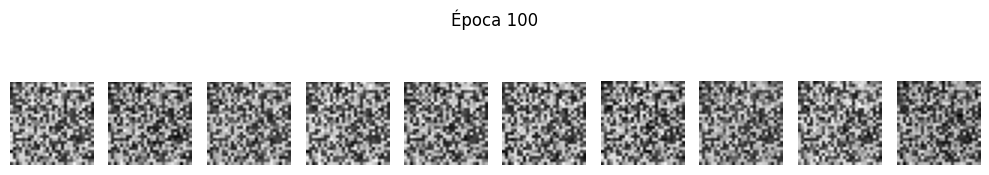

  ⚠️  Posible mode collapse detectado (similitud promedio: 0.964)
Epoch  200/500 | D loss: 2.6260, acc: 0.5% | G loss: 0.0175 | ⏱ 21.7s


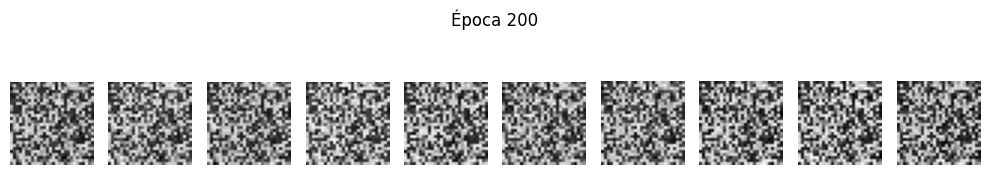

  ⚠️  Posible mode collapse detectado (similitud promedio: 0.963)
Epoch  300/500 | D loss: 3.0328, acc: 0.4% | G loss: 0.0118 | ⏱ 28.9s


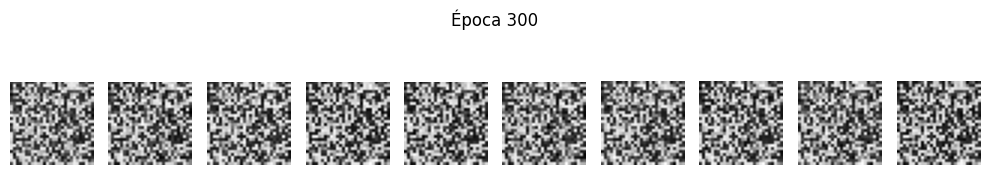

  ⚠️  Posible mode collapse detectado (similitud promedio: 0.964)
Epoch  400/500 | D loss: 3.3319, acc: 0.3% | G loss: 0.0090 | ⏱ 35.7s


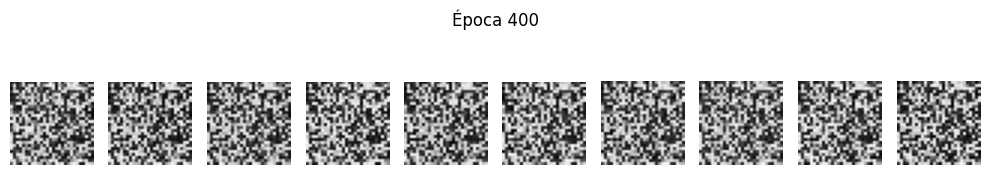

  ⚠️  Posible mode collapse detectado (similitud promedio: 0.964)

✅ Entrenamiento completo en 42.3s (0.7 min)


In [3]:
import time

def sample_images(epoch, n=10):
    noise = np.random.normal(0, 1, (n, LATENT_DIM))
    gen_imgs = generator.predict(noise, verbose=0)
    gen_imgs = gen_imgs.reshape(n, 28, 28)
    plt.figure(figsize=(n, 2))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(gen_imgs[i], cmap='gray')
        plt.axis('off')
    plt.suptitle(f'Época {epoch}')
    plt.tight_layout()
    plt.show()

def check_mode_collapse(gen_imgs, threshold=0.95):
    """Detecta mode collapse calculando la similitud media entre imágenes generadas."""
    gen_flat = gen_imgs.reshape(len(gen_imgs), -1)
    norms = np.linalg.norm(gen_flat, axis=1, keepdims=True)
    gen_norm = gen_flat / (norms + 1e-8)
    sim_matrix = gen_norm @ gen_norm.T
    np.fill_diagonal(sim_matrix, 0)
    avg_sim = sim_matrix.mean()
    if avg_sim > threshold:
        print(f'  ⚠️  Posible mode collapse detectado (similitud promedio: {avg_sim:.3f})')
    return avg_sim

def train_gan(epochs=500, batch_size=128, sample_interval=100):
    half_batch = batch_size // 2
    d_losses, g_losses, d_accs = [], [], []

    start_time = time.time()

    for epoch in range(epochs):
        # Entrenar discriminador
        idx = np.random.randint(0, X_train.shape[0], half_batch)
        real_imgs = X_train[idx]
        noise = np.random.normal(0, 1, (half_batch, LATENT_DIM))
        gen_imgs = generator.predict(noise, verbose=0)

        # Label smoothing: 0.9 en vez de 1.0 para reales
        d_loss_real = discriminator.train_on_batch(real_imgs, np.ones((half_batch, 1)) * 0.9)
        d_loss_fake = discriminator.train_on_batch(gen_imgs, np.zeros((half_batch, 1)))
        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

        # Entrenar generador
        noise = np.random.normal(0, 1, (batch_size, LATENT_DIM))
        g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1)))

        d_losses.append(d_loss[0])
        g_losses.append(g_loss)
        d_accs.append(d_loss[1])

        if epoch % sample_interval == 0:
            elapsed = time.time() - start_time
            print(f'Epoch {epoch:4d}/{epochs} | D loss: {d_loss[0]:.4f}, acc: {100*d_loss[1]:.1f}% '
                  f'| G loss: {g_loss:.4f} | ⏱ {elapsed:.1f}s')
            sample_images(epoch)
            # Diagnóstico de mode collapse
            noise_check = np.random.normal(0, 1, (50, LATENT_DIM))
            imgs_check = generator.predict(noise_check, verbose=0)
            check_mode_collapse(imgs_check)

    total_time = time.time() - start_time
    print(f'\n✅ Entrenamiento completo en {total_time:.1f}s ({total_time/60:.1f} min)')
    return d_losses, g_losses, d_accs

# Entrenar la GAN
d_losses, g_losses, d_accs = train_gan(epochs=500, batch_size=128, sample_interval=100)

### Evolución de las pérdidas

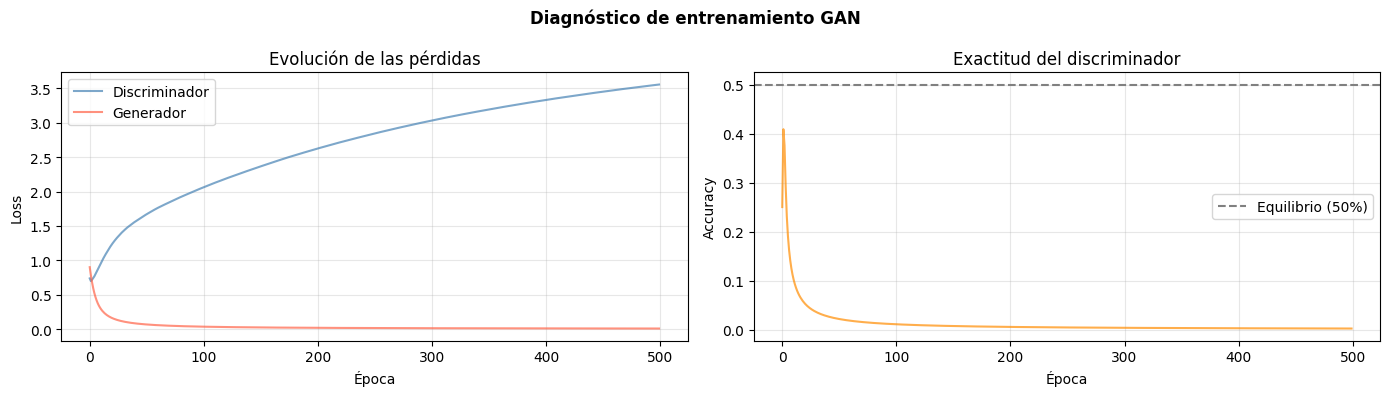

📊 Diagnóstico de convergencia:
  Pérdida D (últimas 50 épocas): 3.5051
  Pérdida G (últimas 50 épocas): 0.0076
  Acc. D   (últimas 50 épocas): 0.2%

💡 Ideal: pérdidas D y G similares, accuracy D cercana al 50% (equilibrio Nash)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(d_losses, label='Discriminador', alpha=0.7, color='steelblue')
axes[0].plot(g_losses, label='Generador', alpha=0.7, color='tomato')
axes[0].set_title('Evolución de las pérdidas')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(d_accs, color='darkorange', alpha=0.7)
axes[1].axhline(0.5, color='gray', linestyle='--', label='Equilibrio (50%)')
axes[1].set_title('Exactitud del discriminador')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Diagnóstico de entrenamiento GAN', fontweight='bold')
plt.tight_layout()
plt.show()

# Análisis de convergencia
print('📊 Diagnóstico de convergencia:')
print(f'  Pérdida D (últimas 50 épocas): {np.mean(d_losses[-50:]):.4f}')
print(f'  Pérdida G (últimas 50 épocas): {np.mean(g_losses[-50:]):.4f}')
print(f'  Acc. D   (últimas 50 épocas): {np.mean(d_accs[-50:])*100:.1f}%')
print('\n💡 Ideal: pérdidas D y G similares, accuracy D cercana al 50% (equilibrio Nash)')

## 5. Resultado final del generador

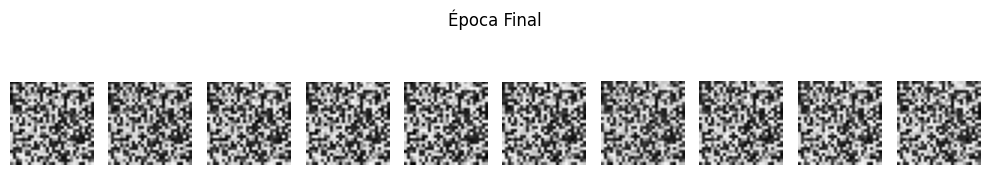

In [5]:
# Generar imágenes finales
sample_images('Final', n=10)

### Recomendaciones prácticas para GANs

| Aspecto | Recomendación |
|---------|---------------|
| **Estabilidad** | Usar BatchNormalization en el generador; LayerNorm en el discriminador |
| **Label smoothing** | Etiquetas reales en [0.8, 1.0] — reduce confianza excesiva del discriminador |
| **Activación** | LeakyReLU (α=0.2) en discriminador; ReLU o LeakyReLU en generador |
| **Mode collapse** | Monitorear diversidad visual; prueba WGAN o espectral normalization |
| **Learning rates** | D y G con LR distintos (e.g., D: 0.0001, G: 0.0002) |
| **Equilibrio** | Si D loss → 0, el generador no aprende; reducir frecuencia de actualización D |
| **Evaluación** | Inspección visual + FID score para calidad objetiva |
| **GPU** | Esencial para más de 1000 epochs en imágenes ≥ 64×64 |

> 💡 **Truco:** Si el discriminador gana demasiado rápido, entrena el generador 2× por cada actualización del discriminador (`n_critic = 2`).

> ⚠️ **Mode collapse:** Si todas las imágenes generadas se ven iguales, la función `check_mode_collapse()` lo detectará. Señal para reiniciar o cambiar arquitectura.

## 6. Discusión y Conclusiones

**¿Qué aprendimos?**

- Las GANs funcionan mediante un **juego de suma cero**: generador y discriminador mejoran mutuamente.
- **BatchNormalization** en el generador y **label smoothing** en el discriminador son técnicas clave para estabilizar el entrenamiento.
- La **accuracy del discriminador** cerca del 50% indica equilibrio — es la señal de convergencia saludable en una GAN.
- El **mode collapse** es el problema más común: el generador colapsa en pocas variantes de salida. La función `check_mode_collapse()` permite detectarlo automáticamente.
- Las curvas de pérdida de GANs son inherentemente ruidosas; lo importante es la tendencia y la calidad visual.

**Para llevar:**
- Monitorear siempre visualmente las imágenes generadas en intervalos regulares.
- Para calidad real en producción, considerar **DCGAN** (convolucional), **StyleGAN** o **Diffusion Models** (estado del arte actual).
- El FID (Fréchet Inception Distance) es la métrica estándar para evaluar GANs objetivamente.

En el siguiente notebook veremos **Autoencoders**, otra familia de modelos generativos con espacio latente explícito.

## 7. Ejercicios Propuestos

1. **Ejercicio 1:** Entrena con más epochs (2000-5000). ¿Mejora la calidad visual de los dígitos generados?

2. **Ejercicio 2:** Cambia el dataset a Fashion MNIST. ¿La GAN puede generar prendas de ropa reconocibles?

3. **Ejercicio 3:** Implementa una DCGAN (GAN con capas convolucionales) para mejor calidad de imagen.

4. **Ejercicio 4 (Avanzado):** Implementa una Conditional GAN (cGAN) que permita generar un dígito específico pasando la clase como condición.

## 8. Referencias y Recursos

- [TensorFlow DCGAN Tutorial](https://www.tensorflow.org/tutorials/generative/dcgan)
- Goodfellow et al. (2014). *Generative Adversarial Nets.*
- [GAN Lab (Interactivo)](https://poloclub.github.io/ganlab/)
- Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow.*

---

📎 **Notebook anterior:** [07. Transformers y Atención](./07_transformers.ipynb)  
📎 **Notebook siguiente:** [09. Autoencoders](./09_autoencoders.ipynb)